## Setup

In [28]:
import os
import sys
import logging
from pathlib import Path

# Add parent directory to path to import celltype_standardizer
sys.path.insert(0, str(Path.cwd().parent))

import anndata as ad
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from celltype_standardizer import standardize_h5ad_and_update_mapping, evaluate_h5ad
from celltype_standardizer.standardize import get_label_coverage_report

# Configure logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(name)s - %(levelname)s - %(message)s')

# Set your OpenAI API key here or via environment variable
# os.environ['OPENAI_API_KEY'] = 'your-api-key-here'

print("Setup complete!")

Setup complete!


In [29]:
# Load API key from config file
import json

config_path = Path('../config/config.json')
if config_path.exists():
    with open(config_path, 'r') as f:
        config = json.load(f)
    
    api_key = config.get('openai', {}).get('api_key')
    
    if api_key and api_key != 'YOUR_OPENAI_API_KEY_HERE':
        os.environ['OPENAI_API_KEY'] = api_key
        print("✓ API key loaded from config.json")
    else:
        print("⚠️  Please set your API key in config/config.json")
        print("   or set it here: os.environ['OPENAI_API_KEY'] = 'your-key'")
else:
    print("⚠️  Config file not found. Set API key manually:")
    print("   os.environ['OPENAI_API_KEY'] = 'your-key'")


✓ API key loaded from config.json


## Load Debug Datasets

In [30]:
# Define paths
data_dir = Path('../../dataset')
# gt_file = data_dir / 'datasetGT_debug.h5ad'
gt_file = Path('/cs/student/projects2/aisd/2024/shekchu/projects/data/brain/h5ad/Data_Choudhury2022_Brain.h5ad')

# # test_file = data_dir / 'datasetTest_debug.h5ad'
test_file = Path('/cs/student/projects2/aisd/2024/shekchu/projects/cell_agents/agents/mLLMCellType/output/brain_choudhury2022_celltype_annotation.h5ad')

# Check if files exist
print(f"Ground truth file exists: {gt_file.exists()}")
# print(f"Test file exists: {test_file.exists()}")

# Load datasets
if gt_file.exists():
    adata_gt = ad.read_h5ad(gt_file)
    print(f"\nGround truth dataset: {adata_gt.shape[0]} cells")
    print(f"Obs columns: {list(adata_gt.obs.columns)}")
    
if test_file.exists():
    adata_test = ad.read_h5ad(test_file)
    print(f"\nTest dataset: {adata_test.shape[0]} cells")
    print(f"Obs columns: {list(adata_test.obs.columns)}")

Ground truth file exists: True

Ground truth dataset: 58843 cells
Obs columns: ['sample', 'patient', 'cell_type', 'cell_subtype', 'complexity', 'umap1', 'umap2', 'g1s_score', 'g2m_score', 'cell_cycle_phase', 'mp_top_score', 'mp_top', 'mp_assignment', 'source', '__part']

Test dataset: 58843 cells
Obs columns: ['leiden', 'openrouter_cell_type']


## ⚠️ Important: QC Filtering & Cell Matching

**Why do cell counts differ?**

BioMaster and other pipelines apply Quality Control (QC) filtering that removes low-quality cells:
- Cells with ≥20% mitochondrial genes (dying cells)
- Cells with <500 total counts (low sequencing depth)
- Cells with <200 detected genes (poor quality)

**How does evaluation handle this?**

The evaluation system automatically:
1. **Finds common cells** between ground truth and predictions (by cell barcode)
2. **Evaluates only the overlapping subset** - ensures fair comparison
3. **Reports cell matching statistics** - shows how many cells were filtered

This approach:
- ✅ Handles QC filtering automatically
- ✅ Ensures predictions and GT have the same cells
- ✅ Provides metrics on the cells that passed QC
- ✅ No manual preprocessing needed!

## Workflow 1: Standalone Standardization

First, let's check the coverage of our ground truth labels and then standardize them.

In [31]:
# ========== WORKFLOW 1: STANDALONE STANDARDIZATION ==========
# This cell runs the complete Workflow 1 in one click

if gt_file.exists():
    # Step 1: Inspect available label columns
    print("=" * 60)
    print("STEP 1: Inspect Label Columns")
    print("=" * 60)
    print("Available columns in ground truth:")
    print(adata_gt.obs.columns.tolist())
    
    # Check for common cell-type column names
    possible_columns = ['cell_type', 'celltype', 'cell_ontology_class', 'leiden', 'louvain']
    gt_label_column = None
    
    for col in possible_columns:
        if col in adata_gt.obs.columns:
            gt_label_column = col
            print(f"\nUsing column: {gt_label_column}")
            print(f"Unique labels: {adata_gt.obs[col].nunique()}")
            print(f"Sample labels: {adata_gt.obs[col].unique()[:10]}")
            break
    
    if gt_label_column is None:
        print("\nPlease specify the correct column name for cell-type labels")
        gt_label_column = 'cell_type'  # Default fallback
    
    # Step 2: Check label coverage
    print("\n" + "=" * 60)
    print("STEP 2: Check Label Coverage")
    print("=" * 60)
    
    coverage = get_label_coverage_report(
        input_h5ad=gt_file,
        obs_column=gt_label_column
    )
    
    print(f"Total unique labels: {coverage['total_unique_labels']}")
    print(f"Already mapped: {coverage['mapped_count']} ({coverage['coverage_percent']:.1f}%)")
    print(f"Need mapping: {coverage['unmapped_count']}")
    
    if coverage['unmapped_labels']:
        print(f"\nUnmapped labels (first 20):")
        for label in coverage['unmapped_labels'][:20]:
            print(f"  - {label}")
    
    # Step 3: Standardize to L3 (in memory only, no file saved)
    print("\n" + "=" * 60)
    print("STEP 3: Standardize Labels to L3")
    print("=" * 60)
    print("Note: Labels will be standardized in memory for visualization")
    print("No file will be saved - evaluation handles standardization automatically\n")
    
    adata_gt_standardized = standardize_h5ad_and_update_mapping(
        input_h5ad=gt_file,
        obs_column=gt_label_column,
        output_h5ad=None,  # Don't save - evaluation will standardize on-the-fly
        output_obs_column='cell_type_level3',
        skip_llm=False,  # Set to True to skip LLM calls
    )
    
    print("\n" + "=" * 60)
    print("WORKFLOW 1 COMPLETE!")
    print("=" * 60)
    print(f"L3 labels added to column: 'cell_type_level3' (in memory)")
    print(f"Unique L3 labels: {adata_gt_standardized.obs['cell_type_level3'].nunique()}")
    print(f"\nL3 label distribution:")
    print(adata_gt_standardized.obs['cell_type_level3'].value_counts())
else:
    print("⚠️  Ground truth file not found!")

STEP 1: Inspect Label Columns
Available columns in ground truth:
['sample', 'patient', 'cell_type', 'cell_subtype', 'complexity', 'umap1', 'umap2', 'g1s_score', 'g2m_score', 'cell_cycle_phase', 'mp_top_score', 'mp_top', 'mp_assignment', 'source', '__part']

Using column: cell_type
Unique labels: 6
Sample labels: ['Malignant', 'Monocyte', 'Pericyte', 'T_cell', 'Glia', 'Endothelial']
Categories (6, object): ['Endothelial', 'Glia', 'Malignant', 'Monocyte', 'Pericyte', 'T_cell']

STEP 2: Check Label Coverage


2026-03-10 20:56:40,631 - celltype_standardizer.standardize - INFO - === Starting standardization workflow ===
2026-03-10 20:56:40,632 - celltype_standardizer.standardize - INFO - Loading AnnData from /cs/student/projects2/aisd/2024/shekchu/projects/data/brain/h5ad/Data_Choudhury2022_Brain.h5ad


Total unique labels: 6
Already mapped: 6 (100.0%)
Need mapping: 0

STEP 3: Standardize Labels to L3
Note: Labels will be standardized in memory for visualization
No file will be saved - evaluation handles standardization automatically



2026-03-10 20:57:10,582 - celltype_standardizer.standardize - INFO - Found 6 unique raw labels in column 'cell_type'
2026-03-10 20:57:10,585 - celltype_standardizer.standardize - INFO - Mapping store stats: {'total_mappings': 104, 'last_updated': '2026-02-23T11:06:21.416534', 'file_path': '/cs/student/projects2/aisd/2024/shekchu/projects/celltype_eval_llm/mappings/label_mappings.json'}
2026-03-10 20:57:10,587 - celltype_standardizer.standardize - INFO - Found 0 labels without existing mappings
2026-03-10 20:57:10,600 - celltype_standardizer.standardize - INFO - Standardization complete:
2026-03-10 20:57:10,600 - celltype_standardizer.standardize - INFO -   - Standardized to 6 unique L3 labels
2026-03-10 20:57:10,601 - celltype_standardizer.standardize - INFO -   - 0 cells remain unmapped
2026-03-10 20:57:10,601 - celltype_standardizer.standardize - INFO - === Standardization workflow complete ===



WORKFLOW 1 COMPLETE!
L3 labels added to column: 'cell_type_level3' (in memory)
Unique L3 labels: 6

L3 label distribution:
cell_type_level3
Malignant               37449
Myeloid                  8214
Lymphoid                 4635
Fibroblasts              3469
Endothelial              3144
Other_non_neoplastic     1932
Name: count, dtype: int64


## Visualize Ground Truth L3 Distribution

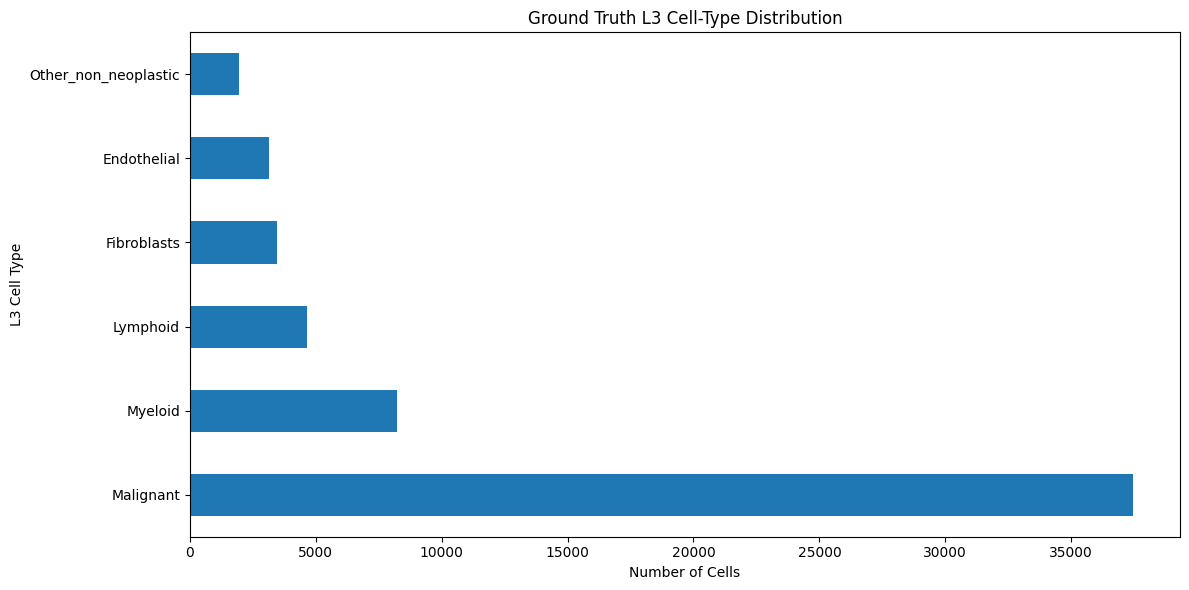

In [32]:
# Plot L3 label distribution
if gt_file.exists() and 'adata_gt_standardized' in locals():
    plt.figure(figsize=(12, 6))
    label_counts = adata_gt_standardized.obs['cell_type_level3'].value_counts()
    
    ax = label_counts.plot(kind='barh')
    plt.xlabel('Number of Cells')
    plt.ylabel('L3 Cell Type')
    plt.title('Ground Truth L3 Cell-Type Distribution')
    plt.tight_layout()
    plt.show()

## Workflow 2: Evaluation

Now let's evaluate predictions from the test dataset against the ground truth.

**Note:** If cell counts differ between GT and predictions (e.g., due to QC filtering),
the evaluation will automatically find and use only the overlapping cells.et

In [33]:
# Debug: Check what columns are in the test file and cell overlap
if test_file.exists():
    print("=" * 60)
    print("DEBUG: Checking columns in test (prediction) file")
    print("=" * 60)
    print("\nTest file columns:", adata_test.obs.columns.tolist())
    
    # Check what columns might be predictions vs ground truth
    possible_pred_cols = ['predicted_cell_type', 'predicted', 'prediction', 'pred_cell_type', 'cell_type_predicted', 'openrouter_cell_type']
    possible_gt_cols = ['cell_type', 'celltype', 'cell_ontology_class', 'true_type', 'ground_truth']
    
    print("\nPotential prediction columns found:")
    for col in possible_pred_cols:
        if col in adata_test.obs.columns:
            print(f"  ✓ {col}")
            print(f"    Sample values: {adata_test.obs[col].unique()[:3]}")
    
    print("\nPotential ground truth columns found:")
    for col in possible_gt_cols:
        if col in adata_test.obs.columns:
            print(f"  ✓ {col}")
            print(f"    Sample values: {adata_test.obs[col].unique()[:3]}")
    
    # Check if there's a 'cell_type' column and what it contains
    if 'cell_type' in adata_test.obs.columns:
        print("\n'cell_type' column stats:")
        print(f"  Unique values: {adata_test.obs['cell_type'].nunique()}")
        print(f"  Top 5 values: {adata_test.obs['cell_type'].value_counts()[:5]}")
    
    # Check overlap with ground truth
    print("\n" + "=" * 60)
    print("Cell Overlap Analysis")
    print("=" * 60)
    if gt_file.exists():
        import numpy as np
        common_cells = np.intersect1d(adata_gt.obs_names, adata_test.obs_names)
        print(f"GT cells: {adata_gt.shape[0]}")
        print(f"Prediction cells: {adata_test.shape[0]}")
        print(f"Overlapping cells: {len(common_cells)}")
        print(f"GT-only cells: {adata_gt.shape[0] - len(common_cells)}")
        print(f"Pred-only cells: {adata_test.shape[0] - len(common_cells)}")
        
        if len(common_cells) < min(adata_gt.shape[0], adata_test.shape[0]):
            print(f"\n⚠️  Evaluation will use only {len(common_cells)} overlapping cells")
            print(f"   (likely due to QC filtering removing low-quality cells)")
        else:
            print(f"\n✓ All cells overlap - no filtering needed")
    
    print("\n" + "=" * 60)
    print("Ground truth file info:")
    print("=" * 60)
    if gt_file.exists() and 'adata_gt_standardized' in locals():
        print(f"\nGT file has been standardized with column: 'cell_type_level3'")
        print(f"Unique L3 labels: {adata_gt_standardized.obs['cell_type_level3'].nunique()}")
        print(f"Top 5 L3 labels: {adata_gt_standardized.obs['cell_type_level3'].value_counts()[:5]}")
else:
    print("⚠️  Test file not found!")

DEBUG: Checking columns in test (prediction) file

Test file columns: ['leiden', 'openrouter_cell_type']

Potential prediction columns found:
  ✓ openrouter_cell_type
    Sample values: ['PTGDS+ perivascular / leptomeningeal fibrobla..., 'PTGDS+ leptomeningeal / arachnoidperivascular..., 'Perivascular / border-associated macrophages']
Categories (32, object): ['Activated MHCII+ C1Q+ microglia / brainreside..., 'Activated antigen-presenting microglia', 'Angiogenic / tiplike brain endothelial cells', 'Astrocytes (stress/reactivelike astrocytes)', ..., 'Proliferating cells', 'SPP1+ activated microglia', 'SPP1+ activated brain macrophages', 'T lymphocytes']

Potential ground truth columns found:

Cell Overlap Analysis
GT cells: 58843
Prediction cells: 58843
Overlapping cells: 58843
GT-only cells: 0
Pred-only cells: 0

✓ All cells overlap - no filtering needed

Ground truth file info:

GT file has been standardized with column: 'cell_type_level3'
Unique L3 labels: 6
Top 5 L3 labels: cell_ty

## Debug: Check Columns and Data

In [34]:
# ========== WORKFLOW 2: EVALUATION ==========
# This cell runs the complete Workflow 2 in one click
# IMPORTANT: Automatically handles cell count mismatches (e.g., due to QC filtering)

if test_file.exists() and gt_file.exists():
    # Step 1: Identify prediction column in test file
    print("=" * 60)
    print("STEP 1: Identify Columns")
    print("=" * 60)
    print("Available columns in test (prediction) dataset:")
    print(adata_test.obs.columns.tolist())
    
    # BioMaster typically outputs predictions in 'cell_type' column
    # You may need to adjust this based on your agent's output format
    test_pred_column = "openrouter_cell_type"  # Update if BioMaster uses a different column name
    
    # Use original column name (will be standardized during evaluation)
    gt_label_column = 'cell_type'
    
    print(f"\nPrediction column (from test file): {test_pred_column}")
    print(f"Ground truth column (from GT file): {gt_label_column}")
    print(f"\nTest file: {test_file.name}")
    print(f"Ground truth file: {gt_file.name}")
    
    # Verify the columns exist
    if test_pred_column not in adata_test.obs.columns:
        print(f"\n⚠️  ERROR: Column '{test_pred_column}' not found in test file!")
        print("Please update test_pred_column to the correct prediction column name")
    else:
        # Step 2: Check cell counts (informational)
        print("\n" + "=" * 60)
        print("STEP 1.5: Check Cell Counts")
        print("=" * 60)
        
        adata_gt_check = ad.read_h5ad(gt_file)
        print(f"Ground truth cells: {adata_gt_check.shape[0]}")
        print(f"Test (prediction) cells: {adata_test.shape[0]}")
        
        if adata_gt_check.shape[0] == adata_test.shape[0]:
            print("✓ Cell counts match")
        else:
            print("⚠️  Cell counts don't match (likely due to QC filtering)")
            print("   → Evaluation will automatically match cells by barcode")
        
        print(f"\nSample predictions ({test_pred_column}):")
        print(adata_test.obs[test_pred_column].value_counts()[:5])
        
        # Step 3: Run evaluation (automatically matches cells on overlapping subset)
        print("\n" + "=" * 60)
        print("STEP 2: Running Evaluation")
        print("=" * 60 + "\n")
        print(f"Using ground truth: {gt_file.name}")
        print("Evaluation will:")
        print("  1. Find common cells between GT and predictions")
        print("  2. Evaluate only on the overlapping subset")
        print("  3. Standardize both to L3 labels\n")
        
        metrics = evaluate_h5ad(
            pred_h5ad=test_file,
            pred_column=test_pred_column,
            gt_h5ad=gt_file,  # Always use original GT file
            gt_column=gt_label_column,  # Use original column name
            metrics_output_path=data_dir / 'evaluation_metrics.json',
            skip_llm=False,  # Set to True to skip LLM calls
        )
        
        print("\n" + "=" * 60)
        print("WORKFLOW 2 COMPLETE - EVALUATION RESULTS")
        print("=" * 60)
        print(f"\nOverall Metrics:")
        print(f"  Accuracy:    {metrics['accuracy']:.4f}")
        print(f"  Macro F1:    {metrics['macro_f1']:.4f}")
        print(f"  Weighted F1: {metrics['weighted_f1']:.4f}")
        
        # Show cell matching info
        if metrics['dataset_info']['cells_filtered']:
            print(f"\nCell Matching:")
            print(f"  Original GT cells:   {metrics['dataset_info']['original_gt_cells']:,}")
            print(f"  Original Pred cells: {metrics['dataset_info']['original_pred_cells']:,}")
            print(f"  Matched cells:       {metrics['dataset_info']['matched_cells']:,}")
            pct_matched = metrics['dataset_info']['matched_cells'] / metrics['dataset_info']['original_pred_cells'] * 100
            print(f"  Evaluation coverage: {pct_matched:.1f}% of predictions")
else:
    if not test_file.exists():
        print("⚠️  Test file not found!")
    if not gt_file.exists():
        print("⚠️  Ground truth file not found!")

STEP 1: Identify Columns
Available columns in test (prediction) dataset:
['leiden', 'openrouter_cell_type']

Prediction column (from test file): openrouter_cell_type
Ground truth column (from GT file): cell_type

Test file: brain_choudhury2022_celltype_annotation.h5ad
Ground truth file: Data_Choudhury2022_Brain.h5ad

STEP 1.5: Check Cell Counts


2026-03-10 20:57:40,517 - celltype_standardizer.evaluate - INFO - === Starting evaluation workflow ===
2026-03-10 20:57:40,517 - celltype_standardizer.evaluate - INFO - Loading prediction data from /cs/student/projects2/aisd/2024/shekchu/projects/cell_agents/agents/mLLMCellType/output/brain_choudhury2022_celltype_annotation.h5ad


Ground truth cells: 58843
Test (prediction) cells: 58843
✓ Cell counts match

Sample predictions (openrouter_cell_type):
openrouter_cell_type
Inflammatory / activated brain pericytes                    6888
Perivascular Fibroblasts / Vascular Leptomeningeal Cells    5906
Housekeepinggenehigh / lowspecificity cluster               4672
ECMremodeling perivascular fibroblasts                      4239
Proliferating cells                                         3400
Name: count, dtype: int64

STEP 2: Running Evaluation

Using ground truth: Data_Choudhury2022_Brain.h5ad
Evaluation will:
  1. Find common cells between GT and predictions
  2. Evaluate only on the overlapping subset
  3. Standardize both to L3 labels



2026-03-10 20:58:03,063 - celltype_standardizer.evaluate - INFO - Loading ground truth data from /cs/student/projects2/aisd/2024/shekchu/projects/data/brain/h5ad/Data_Choudhury2022_Brain.h5ad
2026-03-10 20:58:27,224 - celltype_standardizer.evaluate - INFO - Cell counts match: 58843 cells
2026-03-10 20:58:27,226 - celltype_standardizer.evaluate - INFO - Initial mapping store stats: {'total_mappings': 104, 'last_updated': '2026-02-23T11:06:21.416534', 'file_path': '/cs/student/projects2/aisd/2024/shekchu/projects/celltype_eval_llm/mappings/label_mappings.json'}
2026-03-10 20:58:27,246 - celltype_standardizer.evaluate - INFO - Found 32 unique predicted labels
2026-03-10 20:58:27,246 - celltype_standardizer.evaluate - INFO - Found 6 unique ground truth labels
2026-03-10 20:58:27,246 - celltype_standardizer.evaluate - INFO - Total 38 unique labels to standardize
2026-03-10 20:58:27,249 - celltype_standardizer.evaluate - INFO - Mapping 32 new labels using LLM
2026-03-10 20:58:27,293 - cellty


WORKFLOW 2 COMPLETE - EVALUATION RESULTS

Overall Metrics:
  Accuracy:    0.3153
  Macro F1:    0.5252
  Weighted F1: 0.2733


## Visualize Evaluation Results

In [35]:
# Save evaluation results to a structured folder (matching batch_evaluation format)
if 'metrics' in locals():
    import re
    
    # Parse tissue and dataset name from file path
    # Expected format: data/{tissue}/h5ad/Data_{Dataset}_{Tissue}.h5ad
    gt_file_str = str(gt_file)
    
    # Extract tissue from path (e.g., 'brain', 'breast', etc.)
    tissue_match = re.search(r'/data/([^/]+)/h5ad/', gt_file_str)
    tissue = tissue_match.group(1) if tissue_match else 'unknown_tissue'
    
    # Extract dataset name from filename (e.g., 'Data_Choudhury2022_Brain' -> 'Choudhury2022')
    file_name = gt_file.stem  # Get filename without extension
    dataset_match = re.search(r'Data_([^_]+)', file_name)
    dataset_name = dataset_match.group(1) if dataset_match else file_name
    
    # Create results folder: evaluation_results/{tissue}_{dataset_name}
    # This matches the format used by run_evaluation.py
    results_folder = Path('evaluation_results') / f'{tissue}_{dataset_name}'
    results_folder.mkdir(parents=True, exist_ok=True)
    
    print("=" * 60)
    print("SAVING EVALUATION RESULTS")
    print("=" * 60)
    print(f"Tissue: {tissue}")
    print(f"Dataset: {dataset_name}")
    print(f"Results folder: {results_folder}")
    
    # 1. Save overall metrics to CSV (matching batch_evaluation format)
    overall_metrics_df = pd.DataFrame({
        'Metric': ['Accuracy', 'Macro F1', 'Weighted F1', 'Total Cells', 
                   'Unique Pred Labels (L3)', 'Unique GT Labels (L3)'],
        'Value': [
            metrics['accuracy'],
            metrics['macro_f1'],
            metrics['weighted_f1'],
            metrics['dataset_info']['total_cells'],
            metrics['dataset_info']['standardized_pred_labels'],
            metrics['dataset_info']['standardized_gt_labels']
        ]
    })
    overall_metrics_path = results_folder / 'overall_metrics.csv'
    overall_metrics_df.to_csv(overall_metrics_path, index=False)
    print(f"✓ Saved overall metrics to: {overall_metrics_path.name}")
    
    # 2. Save per-class metrics to CSV (matching batch_evaluation format)
    per_class_df = pd.DataFrame(metrics['per_class_metrics']).T
    per_class_df.index.name = 'Cell_Type_L3'
    per_class_path = results_folder / 'per_class_metrics.csv'
    per_class_df.to_csv(per_class_path)
    print(f"✓ Saved per-class metrics to: {per_class_path.name}")
    
    # 3. Save confusion matrix to CSV (matching batch_evaluation format)
    cm_data = metrics['confusion_matrix']
    cm_df = pd.DataFrame(
        cm_data['matrix'],
        index=cm_data['labels'],
        columns=cm_data['labels']
    )
    cm_df.index.name = 'True_Label'
    cm_df.columns.name = 'Predicted_Label'
    cm_path = results_folder / 'confusion_matrix.csv'
    cm_df.to_csv(cm_path)
    print(f"✓ Saved confusion matrix to: {cm_path.name}")
    
    # 4. Save full metrics JSON (matching batch_evaluation format)
    metrics_json_path = results_folder / 'evaluation_metrics.json'
    import json
    with open(metrics_json_path, 'w') as f:
        json.dump(metrics, f, indent=2)
    print(f"✓ Saved evaluation metrics JSON to: {metrics_json_path.name}")
    
    # Store results_folder path for visualization cells to use
    print(f"\n✓ All results saved to: {results_folder}/")
    print("=" * 60)
else:
    print("⚠️  No metrics available to save. Run evaluation first!")

SAVING EVALUATION RESULTS
Tissue: brain
Dataset: Choudhury2022
Results folder: evaluation_results/brain_Choudhury2022
✓ Saved overall metrics to: overall_metrics.csv
✓ Saved per-class metrics to: per_class_metrics.csv
✓ Saved confusion matrix to: confusion_matrix.csv
✓ Saved evaluation metrics JSON to: evaluation_metrics.json

✓ All results saved to: evaluation_results/brain_Choudhury2022/


## Save Evaluation Results

✓ Saved per-class metrics plot to: per_class_metrics.png


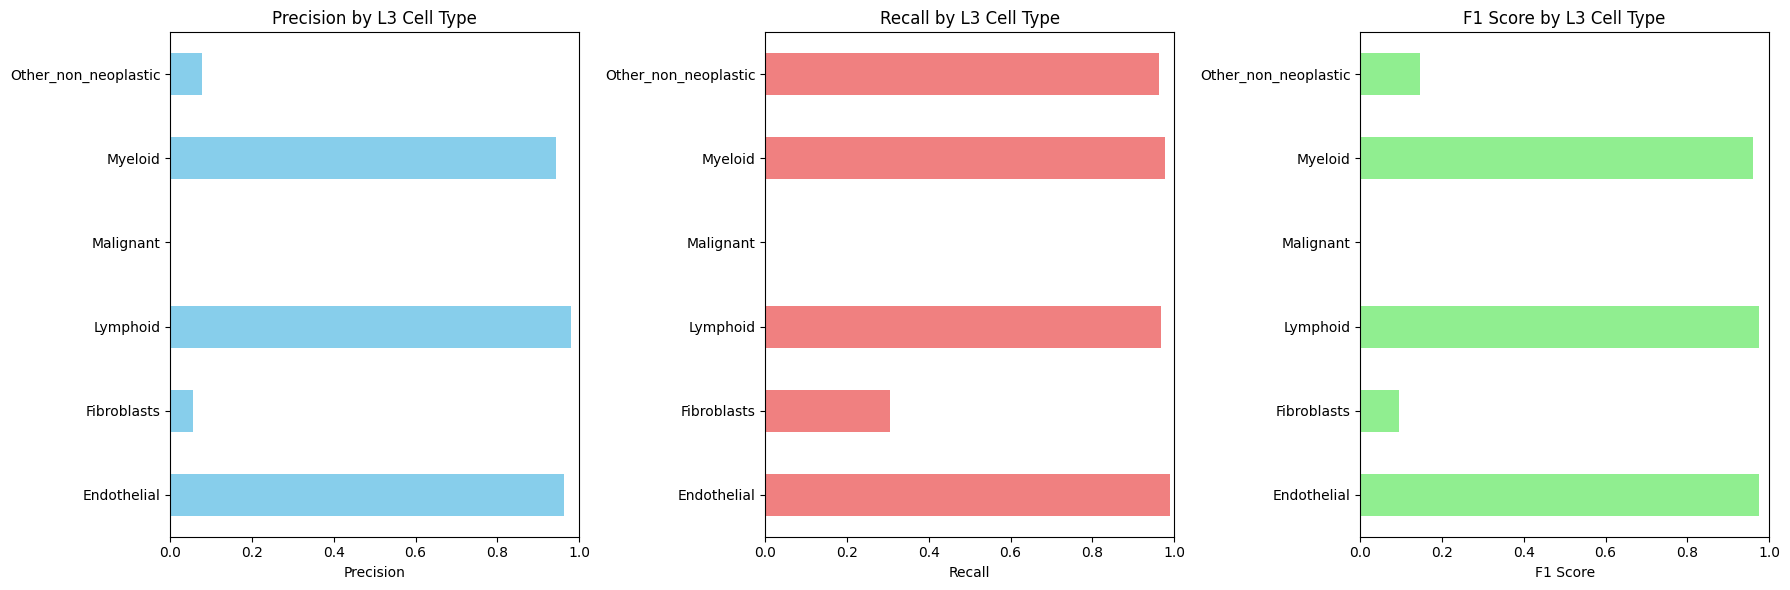

In [36]:
# Plot per-class metrics and save (matching batch_evaluation format)
if 'metrics' in locals() and 'results_folder' in locals():
    per_class = pd.DataFrame(metrics['per_class_metrics']).T
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    per_class['precision'].plot(kind='barh', ax=axes[0], color='skyblue')
    axes[0].set_title('Precision by L3 Cell Type')
    axes[0].set_xlabel('Precision')
    axes[0].set_xlim([0, 1])
    
    per_class['recall'].plot(kind='barh', ax=axes[1], color='lightcoral')
    axes[1].set_title('Recall by L3 Cell Type')
    axes[1].set_xlabel('Recall')
    axes[1].set_xlim([0, 1])
    
    per_class['f1_score'].plot(kind='barh', ax=axes[2], color='lightgreen')
    axes[2].set_title('F1 Score by L3 Cell Type')
    axes[2].set_xlabel('F1 Score')
    axes[2].set_xlim([0, 1])
    
    plt.tight_layout()
    
    # Save the plot
    plot_path = results_folder / 'per_class_metrics.png'
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    print(f"✓ Saved per-class metrics plot to: {plot_path.name}")
    
    plt.show()
elif 'metrics' not in locals():
    print("⚠️  No metrics available. Run evaluation first!")
elif 'results_folder' not in locals():
    print("⚠️  Results folder not created. Run the 'Save Evaluation Results' cell first!")

✓ Saved confusion matrix plot to: confusion_matrix.png


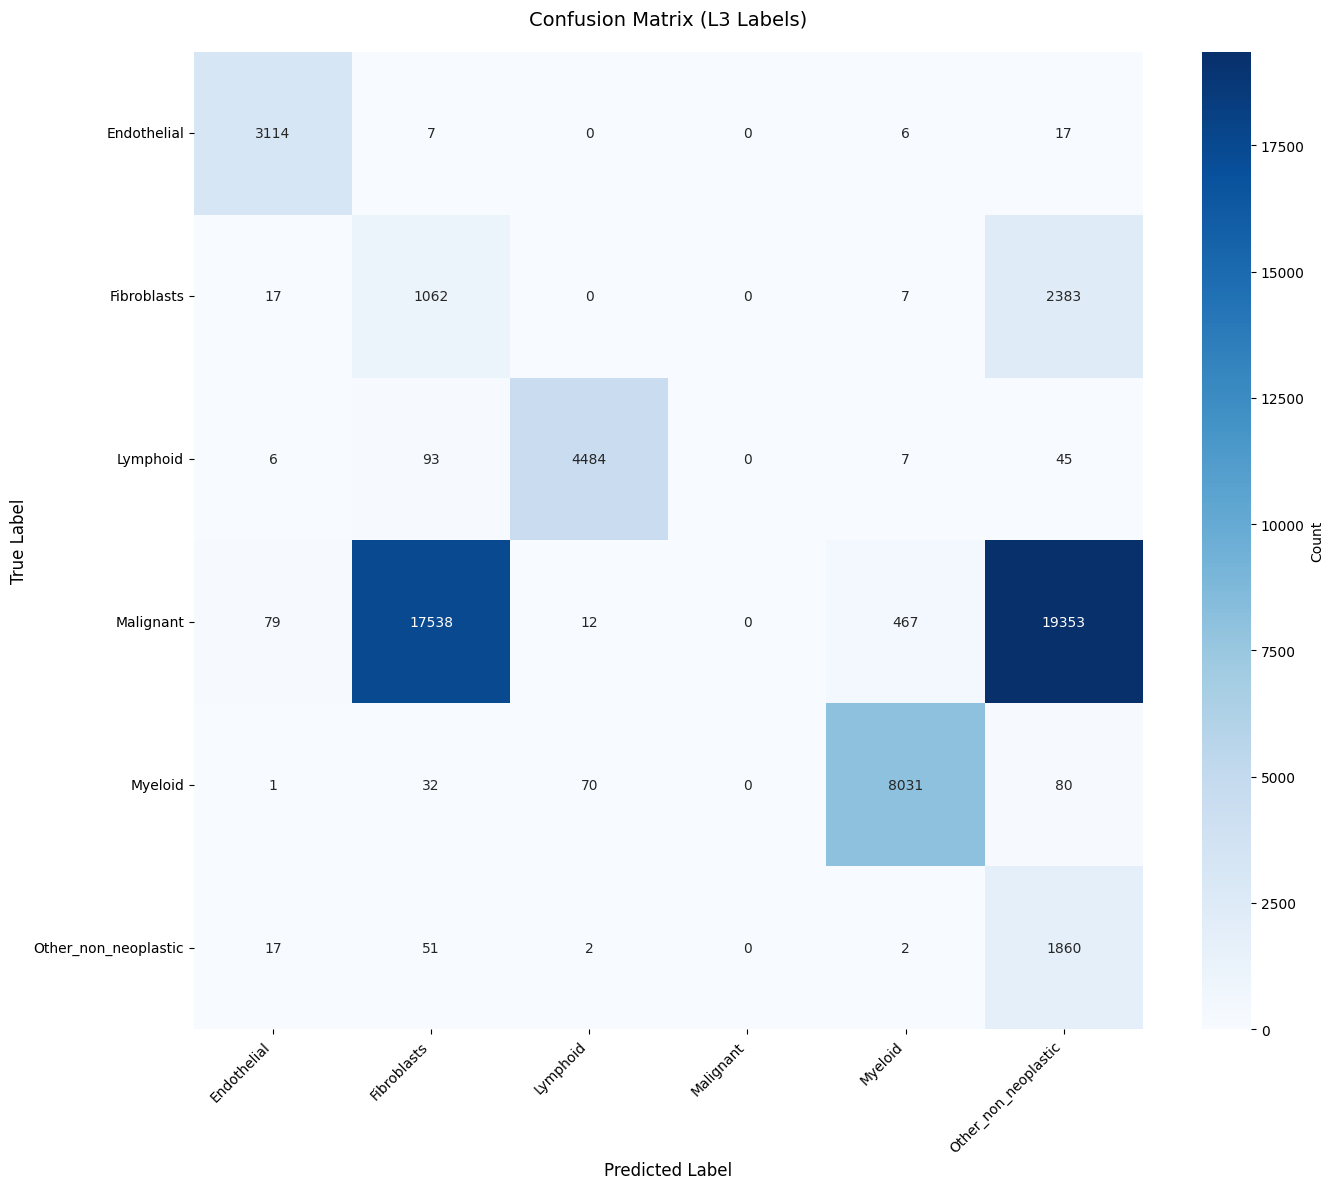

In [37]:
# Plot confusion matrix and save (matching batch_evaluation format)
if 'metrics' in locals() and 'results_folder' in locals():
    import numpy as np
    
    cm_data = metrics['confusion_matrix']
    cm_matrix = np.array(cm_data['matrix'])
    labels = cm_data['labels']
    
    plt.figure(figsize=(14, 12))
    sns.heatmap(
        cm_matrix, 
        annot=True, 
        fmt='d', 
        cmap='Blues',
        xticklabels=labels,
        yticklabels=labels,
        cbar_kws={'label': 'Count'}
    )
    plt.title('Confusion Matrix (L3 Labels)', fontsize=14, pad=20)
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    
    # Save the plot
    plot_path = results_folder / 'confusion_matrix.png'
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    print(f"✓ Saved confusion matrix plot to: {plot_path.name}")
    
    plt.show()
elif 'metrics' not in locals():
    print("⚠️  No metrics available. Run evaluation first!")
elif 'results_folder' not in locals():
    print("⚠️  Results folder not created. Run the 'Save Evaluation Results' cell first!")

In [38]:
# Display summary of saved results (matching batch_evaluation format)
if 'results_folder' in locals() and results_folder.exists():
    print("=" * 60)
    print("EVALUATION RESULTS SUMMARY")
    print("=" * 60)
    print(f"\nResults saved to: {results_folder}/")
    print("\nFiles created:")
    
    # List files in the order they're created  
    expected_files = [
        'overall_metrics.csv',
        'per_class_metrics.csv',
        'confusion_matrix.csv',
        'evaluation_metrics.json',
        'per_class_metrics.png',
        'confusion_matrix.png'
    ]
    
    for filename in expected_files:
        file_path = results_folder / filename
        if file_path.exists():
            file_size = file_path.stat().st_size / 1024  # Size in KB
            print(f"  ✓ {filename} ({file_size:.1f} KB)")
    
    print("\nFile descriptions:")
    print("  • overall_metrics.csv - Accuracy, F1 scores, dataset info")
    print("  • per_class_metrics.csv - Precision, recall, F1 per cell type")
    print("  • confusion_matrix.csv - Full confusion matrix")
    print("  • evaluation_metrics.json - Complete metrics in JSON format")
    print("  • per_class_metrics.png - Bar charts of precision/recall/F1")
    print("  • confusion_matrix.png - Heatmap of confusion matrix")
    
    print("\n" + "=" * 60)
else:
    print("⚠️  No results folder found. Run evaluation and save cells first!")

# Also print the evaluation metrics summary
if 'metrics' in locals():
    print("\n" + "=" * 60)
    print("EVALUATION METRICS")
    print("=" * 60)
    print(f"\nOverall Metrics:")
    print(f"  Accuracy:    {metrics['accuracy']:.4f}")
    print(f"  Macro F1:    {metrics['macro_f1']:.4f}")
    print(f"  Weighted F1: {metrics['weighted_f1']:.4f}")
    print(f"\nDataset Info:")
    print(f"  Total Cells: {metrics['dataset_info']['total_cells']}")
    if metrics['dataset_info']['cells_filtered']:
        print(f"  Original GT cells:   {metrics['dataset_info']['original_gt_cells']:,}")
        print(f"  Original Pred cells: {metrics['dataset_info']['original_pred_cells']:,}")
        print(f"  Matched cells:       {metrics['dataset_info']['matched_cells']:,}")
        pct = metrics['dataset_info']['matched_cells'] / metrics['dataset_info']['original_pred_cells'] * 100
        print(f"  Coverage: {pct:.1f}% of predictions")
    print(f"  Unique Pred Labels (L3): {metrics['dataset_info']['standardized_pred_labels']}")
    print(f"  Unique GT Labels (L3): {metrics['dataset_info']['standardized_gt_labels']}")
    print("=" * 60)

EVALUATION RESULTS SUMMARY

Results saved to: evaluation_results/brain_Choudhury2022/

Files created:
  ✓ overall_metrics.csv (0.2 KB)
  ✓ per_class_metrics.csv (0.5 KB)
  ✓ confusion_matrix.csv (0.3 KB)
  ✓ evaluation_metrics.json (2.7 KB)
  ✓ per_class_metrics.png (123.1 KB)
  ✓ confusion_matrix.png (285.2 KB)

File descriptions:
  • overall_metrics.csv - Accuracy, F1 scores, dataset info
  • per_class_metrics.csv - Precision, recall, F1 per cell type
  • confusion_matrix.csv - Full confusion matrix
  • evaluation_metrics.json - Complete metrics in JSON format
  • per_class_metrics.png - Bar charts of precision/recall/F1
  • confusion_matrix.png - Heatmap of confusion matrix


EVALUATION METRICS

Overall Metrics:
  Accuracy:    0.3153
  Macro F1:    0.5252
  Weighted F1: 0.2733

Dataset Info:
  Total Cells: 58843
  Unique Pred Labels (L3): 5
  Unique GT Labels (L3): 6


## Results Summary

## Inspect Mapping Store

Let's see what mappings have been learned.

In [39]:
# from celltype_standardizer.mapping_store import MappingStore

# # Load mapping store
# store = MappingStore()
# mappings = store.get_all_mappings()
# stats = store.get_stats()

# print("Mapping Store Statistics:")
# print(f"  Total mappings: {stats['total_mappings']}")
# print(f"  Last updated: {stats['last_updated']}")
# print(f"  File: {stats['file_path']}")

# print(f"\nSample mappings (first 20):")
# for i, (raw, l3) in enumerate(list(mappings.items())[:20]):
#     print(f"  {raw:30s} -> {l3}")

## Summary

This notebook demonstrated:

1. **Workflow 1**: Standalone standardization
   - Check label coverage
   - Standardize raw labels to L3 using LLM semantic matching
   - Update persistent mapping store
   - Save standardized dataset

2. **Workflow 2**: Evaluation (L3 multi-class)
   - Load predictions and ground truth
   - Standardize both to L3 (reusing existing mappings when possible)
   - Compute evaluation metrics (accuracy, F1, confusion matrix)
   - Visualize results

3. **Workflow 3**: Binary Classification Evaluation (NEW)
   - Standardize to L3 first
   - Map L3 labels to binary (malignant vs non-malignant)
   - Compute binary metrics: sensitivity, specificity, precision, recall, F1
   - Visualize binary confusion matrix and metrics

4. **Mapping Store**: Persistent storage that grows over time
   - Mappings are reused across runs
   - LLM is only called for new, unmapped labels
   - Thread-safe with file locking

## Workflow 3: Binary Classification Evaluation

Evaluate binary classification performance: malignant vs non-malignant cells.

This workflow:
1. Standardizes labels to L3 (same as Workflow 1)
2. Maps L3 labels to binary categories based on "malignant" keyword
3. Computes binary classification metrics (sensitivity, specificity, etc.)

In [40]:
# # ========== WORKFLOW 3: BINARY CLASSIFICATION ==========
# # Example: Evaluate binary classification (malignant vs non-malignant)

# if test_file.exists():
#     # Specify prediction and ground truth columns
#     test_pred_column = 'predicted'  # Update with your column name
#     test_gt_column = 'cell_type'    # Update with your column name
    
#     print("=" * 60)
#     print("BINARY CLASSIFICATION EVALUATION")
#     print("=" * 60 + "\n")
    
#     binary_results = evaluate_binary_classification(
#         pred_h5ad=test_file,
#         pred_column=test_pred_column,
#         gt_h5ad=None,  # GT is in same file
#         gt_column=test_gt_column,
#         malignant_keyword="malignant",  # Keyword to identify malignant cells
#         metrics_output_path=data_dir / 'binary_metrics.json',
#         skip_llm=False,
#     )
    
#     print("\n" + "=" * 60)
#     print("BINARY CLASSIFICATION RESULTS")
#     print("=" * 60)
    
#     binary_metrics = binary_results['binary_metrics']
    
#     print(f"\nOverall Metrics:")
#     print(f"  Accuracy:     {binary_metrics['accuracy']:.4f}")
#     print(f"  Macro F1:     {binary_metrics['macro_f1']:.4f}")
#     print(f"  Weighted F1:  {binary_metrics['weighted_f1']:.4f}")
    
#     print(f"\nMalignant Detection:")
#     print(f"  Sensitivity:  {binary_metrics['sensitivity']:.4f}  (True Positive Rate)")
#     print(f"  Specificity:  {binary_metrics['specificity']:.4f}  (True Negative Rate)")
    
#     print(f"\nPer-Class Metrics:")
#     for label in ['malignant', 'non-malignant']:
#         metrics = binary_metrics['per_class_metrics'][label]
#         print(f"\n  {label.upper()}:")
#         print(f"    Precision: {metrics['precision']:.4f}")
#         print(f"    Recall:    {metrics['recall']:.4f}")
#         print(f"    F1-Score:  {metrics['f1_score']:.4f}")
#         print(f"    Support:   {metrics['support']}")
    
#     print(f"\nClass Distribution:")
#     print(f"  Predictions: {binary_metrics['label_counts']['predictions']}")
#     print(f"  Ground Truth: {binary_metrics['label_counts']['ground_truth']}")
    
#     # Show L3 to binary mapping
#     print(f"\n  L3 Label Mapping (sample):")
#     mapping = binary_results['label_mapping']['l3_to_binary']
#     for i, (l3_label, binary_label) in enumerate(list(mapping.items())[:10]):
#         print(f"    {l3_label:30s} -> {binary_label}")
#     if len(mapping) > 10:
#         print(f"    ... and {len(mapping) - 10} more labels")
# else:
#     print("⚠️  Test file not found!")

## Visualize Binary Classification Results

In [41]:
# # Plot binary confusion matrix
# if 'binary_results' in locals():
#     import numpy as np
    
#     binary_metrics = binary_results['binary_metrics']
#     cm_data = binary_metrics['confusion_matrix']
#     cm_matrix = np.array(cm_data['matrix'])
#     labels = cm_data['labels']
    
#     fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
#     # Confusion Matrix - Counts
#     sns.heatmap(
#         cm_matrix, 
#         annot=True, 
#         fmt='d', 
#         cmap='Blues',
#         xticklabels=labels,
#         yticklabels=labels,
#         cbar_kws={'label': 'Count'},
#         ax=axes[0]
#     )
#     axes[0].set_title('Binary Confusion Matrix (Counts)', fontsize=14, pad=20)
#     axes[0].set_ylabel('True Label', fontsize=12)
#     axes[0].set_xlabel('Predicted Label', fontsize=12)
    
#     # Confusion Matrix - Normalized
#     cm_normalized = cm_matrix.astype('float') / cm_matrix.sum(axis=1)[:, np.newaxis]
#     sns.heatmap(
#         cm_normalized, 
#         annot=True, 
#         fmt='.2%', 
#         cmap='Blues',
#         xticklabels=labels,
#         yticklabels=labels,
#         cbar_kws={'label': 'Percentage'},
#         ax=axes[1]
#     )
#     axes[1].set_title('Binary Confusion Matrix (Normalized)', fontsize=14, pad=20)
#     axes[1].set_ylabel('True Label', fontsize=12)
#     axes[1].set_xlabel('Predicted Label', fontsize=12)
    
#     plt.tight_layout()
#     plt.show()

In [42]:
# # Plot binary metrics comparison
# if 'binary_results' in locals():
#     binary_metrics = binary_results['binary_metrics']
    
#     # Create bar plot for key metrics
#     fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
#     # Overall metrics
#     overall_metrics = {
#         'Accuracy': binary_metrics['accuracy'],
#         'Macro F1': binary_metrics['macro_f1'],
#         'Sensitivity\n(Malignant TPR)': binary_metrics['sensitivity'],
#         'Specificity\n(Non-mal TNR)': binary_metrics['specificity']
#     }
    
#     axes[0].bar(overall_metrics.keys(), overall_metrics.values(), color='steelblue', alpha=0.7)
#     axes[0].set_ylim([0, 1])
#     axes[0].set_ylabel('Score', fontsize=12)
#     axes[0].set_title('Binary Classification - Overall Metrics', fontsize=14)
#     axes[0].grid(axis='y', alpha=0.3)
#     for i, (k, v) in enumerate(overall_metrics.items()):
#         axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')
    
#     # Per-class metrics
#     per_class = binary_metrics['per_class_metrics']
#     classes = ['malignant', 'non-malignant']
#     metrics_names = ['precision', 'recall', 'f1_score']
    
#     x = np.arange(len(classes))
#     width = 0.25
    
#     for i, metric in enumerate(metrics_names):
#         values = [per_class[cls][metric] for cls in classes]
#         axes[1].bar(x + i * width, values, width, label=metric.replace('_', ' ').title(), alpha=0.7)
    
#     axes[1].set_ylabel('Score', fontsize=12)
#     axes[1].set_title('Binary Classification - Per-Class Metrics', fontsize=14)
#     axes[1].set_xticks(x + width)
#     axes[1].set_xticklabels(classes)
#     axes[1].set_ylim([0, 1])
#     axes[1].legend()
#     axes[1].grid(axis='y', alpha=0.3)
    
#     plt.tight_layout()
#     plt.show()